C:\Users\arina\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


(np.float64(2675552.75),
 np.float64(2690337.8499999996),
 np.float64(1240947.995),
 np.float64(1254942.305))

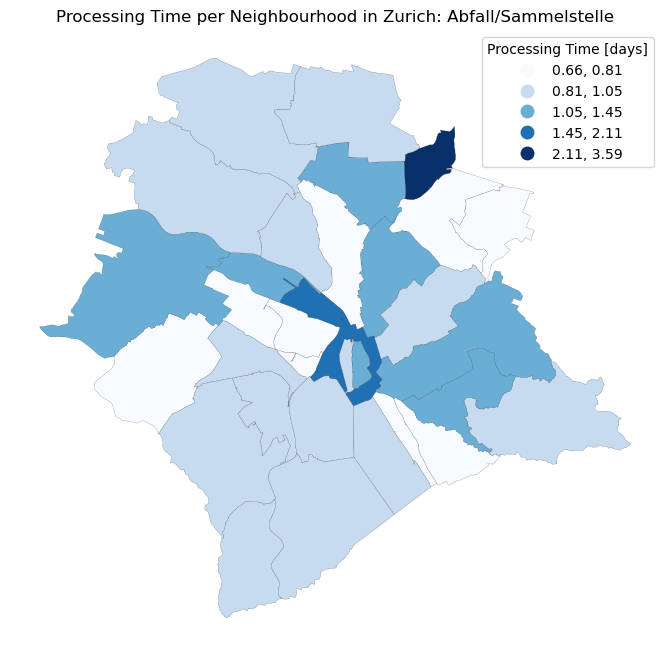

In [88]:
#load data zwn
import pandas as pd
raw_zwn = pd.read_csv("../data/raw/zwn_meldungen.csv")

#Clean data
#select useful columns
processed_zwn = raw_zwn[["service_name","requested_datetime","e","n","status","updated_datetime"]]


#define new columns names
new_names = {
"service_name":"category",
"e":"East",
"n":"North",
"requested_datetime":"report_time",
"updated_datetime":"resolved_time",
    }
processed_zwn= processed_zwn.rename(columns=new_names)

# convert datatype of "report_time" to datetime64
processed_zwn["report_time"] = pd.to_datetime(processed_zwn["report_time"], format ="%Y-%m-%dT%H:%M:%S")
processed_zwn["resolved_time"] = pd.to_datetime(processed_zwn["resolved_time"], format ="%Y-%m-%dT%H:%M:%S")

# create geometry category and geodataframe
import geopandas as gpd
from shapely.geometry import Point
processed_zwn = gpd.GeoDataFrame(processed_zwn,geometry=gpd.points_from_xy(processed_zwn["East"], processed_zwn["North"])
)
# select useful columns
processed_zwn= processed_zwn[["category","report_time","geometry","status","resolved_time"]]


# check missing values
#missing_count = processed_zwn[["category","report_time","geometry"]].isna().sum()
#print(f"The table shows the missing values in the dataframe {missing_count}")

#define missing CRS (CH1903+ / LV95)
processed_zwn = processed_zwn.set_crs(epsg=2056)

# load data quartiere
raw_quartiere = pd.read_csv("../data/raw/quartiere_zürich.csv")
processed_quartiere = raw_quartiere[["qname","geometry"]]
processed_quartiere.head(3)

#define new columns names
new_names1 = {
"qname":"Quartier",
    "geometry": "Geometry"
}
processed_quartiere= processed_quartiere.rename(columns=new_names1)

# check missing values
#missing_count = processed_quartiere[["Quartier","Geometry"]].isna().sum()
#print(f"The table shows the missing values in the dataframe {missing_count}")

#transform geometry datatype
#wkt.loads transform string datatype to geometry data type
from shapely import wkt
processed_quartiere["Geometry"] = processed_quartiere["Geometry"].apply(wkt.loads)

# create geodataframe to interprate "Geometry" as a geometry column
processed_quartiere = gpd.GeoDataFrame(
    processed_quartiere,
    geometry="Geometry")

#define missing CRS (CH1903+ / LV95)
processed_quartiere = processed_quartiere.set_crs(epsg=2056)

#download processed csv-files
#processed_zwn.to_file("../data/processed/processed_zwn.gpkg", driver="GPKG")
#processed_quartiere.to_file("../data/processed/processed_quartiere.gpkg", driver="GPKG")

# Question 4: "Wie unterscheidet sich die Bearbeitungszeit der Quartiere pro Kategorie ? "

#perform spatial join
zwn_with_quartiere = gpd.sjoin(processed_zwn,processed_quartiere, how="left", predicate ="within")

#filter data
#filter only reports which are already fixed
zwn_with_quartiere_filtred= zwn_with_quartiere[zwn_with_quartiere["status"] =="fixed - council"]
zwn_with_quartiere_category= zwn_with_quartiere_filtred[zwn_with_quartiere_filtred["category"]=="Abfall/Sammelstelle"]

#calculate processing time
zwn_with_quartiere_category["processing_time"] = zwn_with_quartiere_category["resolved_time"]-zwn_with_quartiere_category["report_time"]


#calculate mean processing time per Quartier
mean = (zwn_with_quartiere_category.groupby(["Quartier"])["processing_time"].mean().reset_index())

#transform timedelta to floatdata in days 
mean["processing_time_float"]= mean["processing_time"].dt.total_seconds()/86400 #86400s = 1 day



#plot
#import matplotlib.pyplot as plt
#verbindet beide Tabellen über Spalte Quartier
map_df = processed_quartiere.merge(mean, on="Quartier",how="left") #left-->behalte alle Quartiere auch wenn kein Ergebnis existiert
fig, ax = plt.subplots(figsize=(16,8)) # creates empty figure 


#plot
map_df.plot(column="processing_time_float",
            scheme = "naturalbreaks",
            edgecolor = "black",
            legend=True,
            linewidth = 0.1,
            cmap="Blues",
            ax=ax, #draw the axes on the axes we creaed
            legend_kwds={
                "title": "Processing Time [days]",})
ax.set_title("Processing Time per Neighbourhood in Zurich: Abfall/Sammelstelle")

ax.axis("off")

plt.show()



    



C:\Users\arina\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


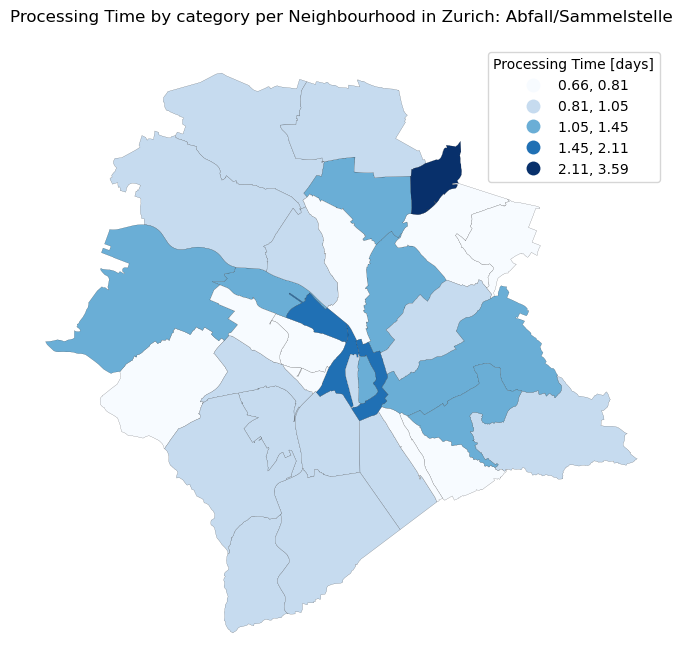

SyntaxError: 'return' outside function (1851504283.py, line 91)

In [90]:
#try function
#load data zwn
import functions
import pandas as pd
raw_zwn = pd.read_csv("../data/raw/zwn_meldungen.csv")

#Clean data
#select useful columns
processed_zwn = raw_zwn[["service_name","requested_datetime","e","n","status","updated_datetime"]]


#define new columns names
new_names = {
"service_name":"category",
"e":"East",
"n":"North",
"requested_datetime":"report_time",
"updated_datetime":"resolved_time",
    }
processed_zwn= processed_zwn.rename(columns=new_names)

# convert datatype of "report_time" to datetime64
processed_zwn["report_time"] = pd.to_datetime(processed_zwn["report_time"], format ="%Y-%m-%dT%H:%M:%S")
processed_zwn["resolved_time"] = pd.to_datetime(processed_zwn["resolved_time"], format ="%Y-%m-%dT%H:%M:%S")

# create geometry category and geodataframe
import geopandas as gpd
from shapely.geometry import Point
processed_zwn = gpd.GeoDataFrame(processed_zwn,geometry=gpd.points_from_xy(processed_zwn["East"], processed_zwn["North"])
)
# select useful columns
processed_zwn= processed_zwn[["category","report_time","geometry","status","resolved_time"]]


# check missing values
#missing_count = processed_zwn[["category","report_time","geometry"]].isna().sum()
#print(f"The table shows the missing values in the dataframe {missing_count}")

#define missing CRS (CH1903+ / LV95)
processed_zwn = processed_zwn.set_crs(epsg=2056)

# load data quartiere
raw_quartiere = pd.read_csv("../data/raw/quartiere_zürich.csv")
processed_quartiere = raw_quartiere[["qname","geometry"]]
processed_quartiere.head(3)

#define new columns names
new_names1 = {
"qname":"Quartier",
    "geometry": "Geometry"
}
processed_quartiere= processed_quartiere.rename(columns=new_names1)

# check missing values
#missing_count = processed_quartiere[["Quartier","Geometry"]].isna().sum()
#print(f"The table shows the missing values in the dataframe {missing_count}")

#transform geometry datatype
#wkt.loads transform string datatype to geometry data type
from shapely import wkt
processed_quartiere["Geometry"] = processed_quartiere["Geometry"].apply(wkt.loads)

# create geodataframe to interprate "Geometry" as a geometry column
processed_quartiere = gpd.GeoDataFrame(
    processed_quartiere,
    geometry="Geometry")

#define missing CRS (CH1903+ / LV95)
processed_quartiere = processed_quartiere.set_crs(epsg=2056)

#download processed csv-files
#processed_zwn.to_file("../data/processed/processed_zwn.gpkg", driver="GPKG")
#processed_quartiere.to_file("../data/processed/processed_quartiere.gpkg", driver="GPKG")

# Question 4: "Wie unterscheidet sich die Bearbeitungszeit der Quartiere pro Kategorie ? "

#perform spatial join
zwn_with_quartiere = gpd.sjoin(processed_zwn,processed_quartiere, how="left", predicate ="within")
zwn_filtred= zwn_with_quartiere[zwn_with_quartiere["status"] =="fixed - council"]


def calculate_mean_processing_time(data,categories):

    for category in categories:
        
        filter_category= data[data["category"]==category]
        filter_category["processing_time"] =  filter_category["resolved_time"]- filter_category["report_time"]
        mean = (filter_category.groupby(["Quartier"])["processing_time"].mean().reset_index())
        mean["processing_time_float"]= mean["processing_time"].dt.total_seconds()/86400 
return mean
calculate_mean_processing_time(zwn_filtred,["Abfall/Sammelstelle"])
#plot
#import matplotlib.pyplot as plt
#verbindet beide Tabellen über Spalte Quartier
map_df = processed_quartiere.merge(mean, on="Quartier",how="left") #left-->behalte alle Quartiere auch wenn kein Ergebnis existiert

fig, ax = plt.subplots(figsize=(16,8)) # creates empty figure 
#plot
map_df.plot(column="processing_time_float",
            scheme = "naturalbreaks",
            edgecolor = "black",
            legend=True,
            linewidth = 0.1,
            cmap="Blues",
            ax=ax, #draw the axes on the axes we creaed
            legend_kwds={
                "title": "Processing Time [days]",})
ax.set_title("Processing Time per Neighbourhood in Zurich: Abfall/Sammelstelle")
ax.axis("off")
plt.show()




 

    
